In [2]:
# ── Imports ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from influxdb_client import InfluxDBClient
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings("ignore")

# ── Style des graphiques ────────────────────────────────────
plt.rcParams["figure.figsize"]  = (16, 5)
plt.rcParams["figure.dpi"]      = 110
plt.rcParams["axes.grid"]       = True
plt.rcParams["grid.alpha"]      = 0.3
plt.rcParams["font.size"]       = 11
sns.set_theme(style="whitegrid")

# ── Connexion InfluxDB ──────────────────────────────────────
load_dotenv()
client = InfluxDBClient(
    url   = os.getenv("INFLUX_URL",   "http://localhost:8086"),
    token = os.getenv("INFLUX_TOKEN", ""),
    org   = os.getenv("INFLUX_ORG",   ""),
)
BUCKET     = os.getenv("INFLUX_BUCKET", "co2_data")
SENSOR_UID = "SENSOR-SCD30-001"

print("✓ Connexion InfluxDB OK")
print(f"  Bucket : {BUCKET}")
print(f"  Capteur : {SENSOR_UID}")

✓ Connexion InfluxDB OK
  Bucket : co2_data
  Capteur : SENSOR-SCD30-001


In [3]:
# ── Requête : toutes les mesures du capteur ─────────────────
# On prend 1 mesure sur 10 pour ne pas charger 2M de lignes en mémoire
# (1 point / 5 min suffit pour l'analyse visuelle)
query = f"""
from(bucket: "{BUCKET}")
  |> range(start: -180d)
  |> filter(fn: (r) => r._measurement == "co2_readings")
  |> filter(fn: (r) => r.sensorId == "{SENSOR_UID}")
  |> filter(fn: (r) => r._field == "co2_ppm" or r._field == "temp_c" or r._field == "hum_pct")
  |> aggregateWindow(every: 5m, fn: mean, createEmpty: false)
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
"""

print("Chargement des données (peut prendre 30-60 secondes)...")
query_api = client.query_api()
df = query_api.query_data_frame(query)

# ── Nettoyage du DataFrame ──────────────────────────────────
df = df.rename(columns={"_time": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

# Colonnes utiles seulement
cols = ["timestamp", "co2_ppm", "temp_c", "hum_pct"]
cols_present = [c for c in cols if c in df.columns]
df = df[cols_present].copy()

# Extraire features temporelles
df["heure"]      = df["timestamp"].dt.hour
df["jour_semaine"]= df["timestamp"].dt.dayofweek   # 0=lundi, 6=dimanche
df["mois"]       = df["timestamp"].dt.month
df["est_weekend"] = df["jour_semaine"] >= 5

print(f"✓ {len(df):,} lignes chargées")
print(f"  Période : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"  Colonnes : {list(df.columns)}")
df.head(3)

Chargement des données (peut prendre 30-60 secondes)...


ApiException: (401)
Reason: Unauthorized
HTTP response headers: HTTPHeaderDict({'Content-Type': 'application/json; charset=utf-8', 'X-Influxdb-Build': 'OSS', 'X-Influxdb-Version': 'v2.8.0', 'X-Platform-Error-Code': 'unauthorized', 'Date': 'Wed, 03 Jun 2026 10:16:53 GMT', 'Content-Length': '55'})
HTTP response body: b'{"code":"unauthorized","message":"unauthorized access"}'


In [4]:
print("═" * 55)
print("  STATISTIQUES DESCRIPTIVES — CO2, Température, Humidité")
print("═" * 55)

stats = df[["co2_ppm", "temp_c", "hum_pct"]].describe().round(2)
stats.index = ["Nombre", "Moyenne", "Écart-type", "Min", "Q25%", "Médiane", "Q75%", "Max"]
print(stats.to_string())

print("\n── Répartition qualité d'air CO2 ──")
bon      = (df["co2_ppm"] <  800).sum()
attention= ((df["co2_ppm"] >= 800)  & (df["co2_ppm"] < 1000)).sum()
alerte   = ((df["co2_ppm"] >= 1000) & (df["co2_ppm"] < 1500)).sum()
critique = (df["co2_ppm"] >= 1500).sum()
total    = len(df)

print(f"  🟢 Bon      (< 800 ppm)  : {bon:>7,} mesures ({100*bon/total:.1f}%)")
print(f"  🟡 Attention(800-1000)   : {attention:>7,} mesures ({100*attention/total:.1f}%)")
print(f"  🟠 Alerte   (1000-1500)  : {alerte:>7,} mesures ({100*alerte/total:.1f}%)")
print(f"  🔴 Critique (> 1500 ppm) : {critique:>7,} mesures ({100*critique/total:.1f}%)")

═══════════════════════════════════════════════════════
  STATISTIQUES DESCRIPTIVES — CO2, Température, Humidité
═══════════════════════════════════════════════════════


NameError: name 'df' is not defined

NameError: name 'df' is not defined

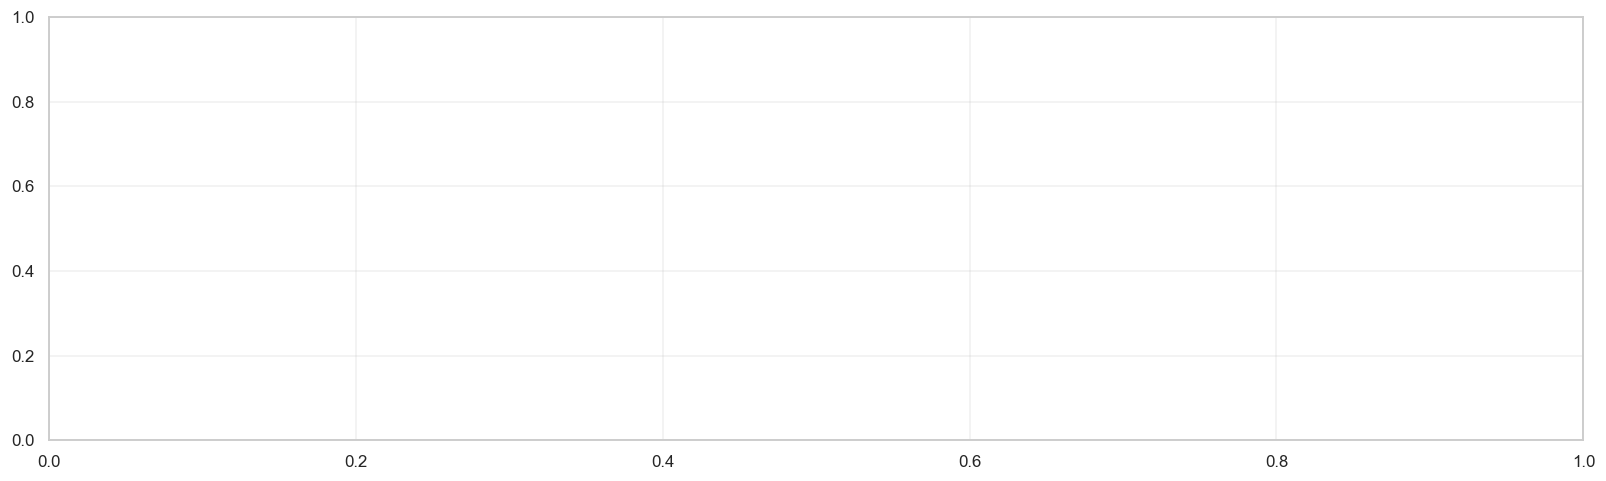

In [5]:
fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(df["timestamp"], df["co2_ppm"],
        color="#2196F3", linewidth=0.4, alpha=0.7, label="CO₂ (ppm)")

# Lignes de seuils
ax.axhline(800,  color="orange", linestyle="--", linewidth=1.2, label="Seuil attention (800 ppm)")
ax.axhline(1000, color="red",    linestyle="--", linewidth=1.2, label="Seuil alerte (1000 ppm)")
ax.axhline(1500, color="darkred",linestyle="--", linewidth=1.2, label="Seuil critique (1500 ppm)")

ax.set_title("Évolution CO₂ sur 6 mois — Capteur SCD30", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("CO₂ (ppm)")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.savefig("eda_co2_6mois.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Graphique sauvegardé : eda_co2_6mois.png")

NameError: name 'df' is not defined

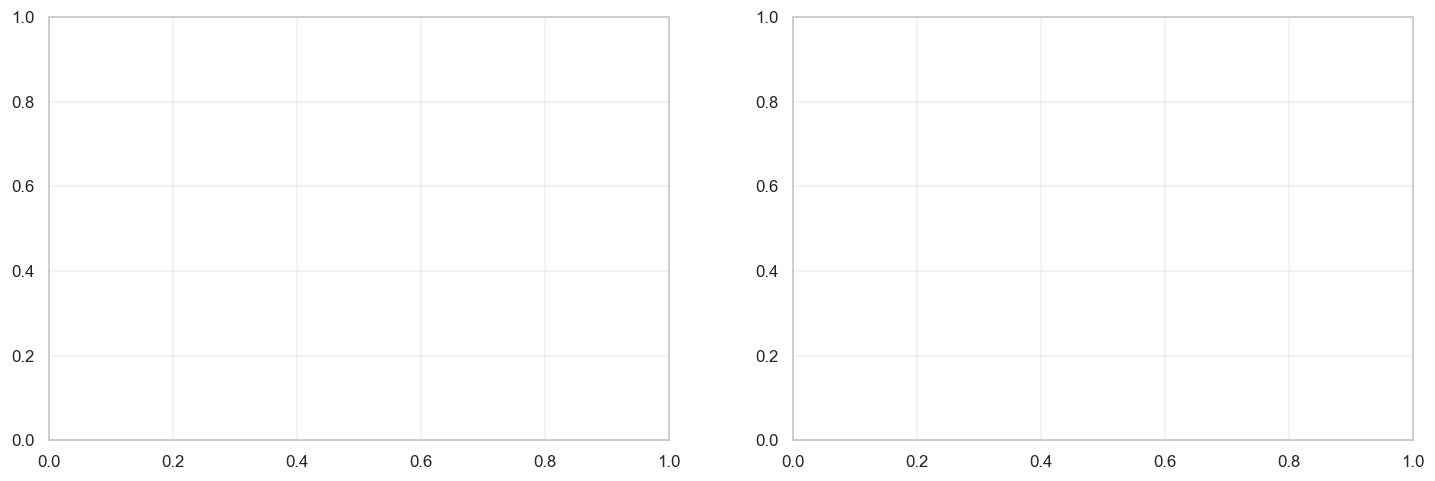

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gauche : CO2 moyen par heure (jour ouvrable vs weekend) ─
jours_ouvrables = df[~df["est_weekend"]]
weekends        = df[df["est_weekend"]]

co2_heure_jo  = jours_ouvrables.groupby("heure")["co2_ppm"].mean()
co2_heure_we  = weekends.groupby("heure")["co2_ppm"].mean()

axes[0].plot(co2_heure_jo.index, co2_heure_jo.values,
             color="#1565C0", linewidth=2.5, marker="o", markersize=4,
             label="Jours ouvrables (Lun-Ven)")
axes[0].plot(co2_heure_we.index, co2_heure_we.values,
             color="#FF7043", linewidth=2.5, marker="s", markersize=4,
             label="Weekend (Sam-Dim)")
axes[0].axhline(800,  color="orange", linestyle="--", linewidth=1, alpha=0.7)
axes[0].axhline(1000, color="red",    linestyle="--", linewidth=1, alpha=0.7)
axes[0].set_title("Profil CO₂ moyen par heure", fontweight="bold")
axes[0].set_xlabel("Heure de la journée")
axes[0].set_ylabel("CO₂ moyen (ppm)")
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# ── Droite : CO2 moyen par jour de la semaine ────────────────
jours_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
co2_jour = df.groupby("jour_semaine")["co2_ppm"].mean()
colors   = ["#1565C0"]*5 + ["#FF7043"]*2

axes[1].bar(jours_labels, co2_jour.values, color=colors, edgecolor="white", linewidth=0.5)
axes[1].axhline(800,  color="orange", linestyle="--", linewidth=1, alpha=0.8, label="Seuil attention")
axes[1].axhline(1000, color="red",    linestyle="--", linewidth=1, alpha=0.8, label="Seuil alerte")
axes[1].set_title("CO₂ moyen par jour de la semaine", fontweight="bold")
axes[1].set_xlabel("Jour")
axes[1].set_ylabel("CO₂ moyen (ppm)")
axes[1].legend()

plt.suptitle("Patterns temporels du CO₂", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_patterns_temporels.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Recharger avec le tag position cette fois
query_pos = f"""
from(bucket: "{BUCKET}")
  |> range(start: -180d)
  |> filter(fn: (r) => r._measurement == "co2_readings")
  |> filter(fn: (r) => r.sensorId == "{SENSOR_UID}")
  |> filter(fn: (r) => r._field == "co2_ppm")
  |> aggregateWindow(every: 30m, fn: mean, createEmpty: false)
  |> keep(columns: ["_time", "_value", "positionId", "posLabel"])
"""

df_pos = query_api.query_data_frame(query_pos)
df_pos = df_pos.rename(columns={"_value": "co2_ppm", "_time": "timestamp"})
df_pos["timestamp"] = pd.to_datetime(df_pos["timestamp"], utc=True)

print(f"✓ {len(df_pos):,} lignes chargées avec positions")
print("Positions trouvées :", df_pos["positionId"].unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gauche : Boxplot CO2 par position ───────────────────────
pos_order  = ["POS-A", "POS-B", "POS-C", "POS-D"]
pos_labels = ["POS-A\nCoin fenêtre", "POS-B\nCentre salle",
              "POS-C\nEntrée", "POS-D\nAngle mort"]
colors_pos = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]

data_by_pos = [df_pos[df_pos["positionId"] == p]["co2_ppm"].dropna().values
               for p in pos_order]

bp = axes[0].boxplot(data_by_pos, labels=pos_labels, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], colors_pos):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].axhline(800,  color="orange", linestyle="--", linewidth=1.2, label="Seuil attention")
axes[0].axhline(1000, color="red",    linestyle="--", linewidth=1.2, label="Seuil alerte")
axes[0].set_title("Distribution CO₂ par position", fontweight="bold")
axes[0].set_ylabel("CO₂ (ppm)")
axes[0].legend()

# ── Droite : Moyenne + écart-type par position ──────────────
stats_pos = df_pos.groupby("positionId")["co2_ppm"].agg(["mean", "std"]).reindex(pos_order)
axes[1].bar(pos_labels, stats_pos["mean"], color=colors_pos,
            alpha=0.8, edgecolor="white")
axes[1].errorbar(pos_labels, stats_pos["mean"], yerr=stats_pos["std"],
                 fmt="none", color="black", capsize=6, linewidth=2)
axes[1].axhline(800,  color="orange", linestyle="--", linewidth=1.2)
axes[1].axhline(1000, color="red",    linestyle="--", linewidth=1.2)
axes[1].set_title("CO₂ moyen ± écart-type par position", fontweight="bold")
axes[1].set_ylabel("CO₂ moyen (ppm)")

# Annotation de la meilleure position
meilleure = stats_pos["mean"].idxmin()
axes[1].annotate("⭐ Meilleure\nposition",
    xy=(pos_order.index(meilleure), stats_pos.loc[meilleure, "mean"]),
    xytext=(pos_order.index(meilleure) + 0.3, stats_pos.loc[meilleure, "mean"] + 80),
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green", fontweight="bold")

plt.suptitle("Comparaison des positions du capteur", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_comparaison_positions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Résumé statistique par position ──")
print(stats_pos.round(1).to_string())
print(f"\n✓ Meilleure position (CO₂ moyen le plus bas) : {meilleure}")

ApiException: (401)
Reason: Unauthorized
HTTP response headers: HTTPHeaderDict({'Content-Type': 'application/json; charset=utf-8', 'X-Influxdb-Build': 'OSS', 'X-Influxdb-Version': 'v2.8.0', 'X-Platform-Error-Code': 'unauthorized', 'Date': 'Wed, 03 Jun 2026 10:18:47 GMT', 'Content-Length': '55'})
HTTP response body: b'{"code":"unauthorized","message":"unauthorized access"}'


In [8]:
# Charger le tag anomaly
query_anom = f"""
from(bucket: "{BUCKET}")
  |> range(start: -180d)
  |> filter(fn: (r) => r._measurement == "co2_readings")
  |> filter(fn: (r) => r.sensorId == "{SENSOR_UID}")
  |> filter(fn: (r) => r._field == "co2_ppm")
  |> aggregateWindow(every: 1h, fn: mean, createEmpty: false)
  |> keep(columns: ["_time", "_value", "anomaly"])
"""

df_anom = query_api.query_data_frame(query_anom)
df_anom = df_anom.rename(columns={"_value": "co2_ppm", "_time": "timestamp"})
df_anom["timestamp"] = pd.to_datetime(df_anom["timestamp"], utc=True)
df_anom["est_anomalie"] = df_anom["anomaly"] != "none"

fig, ax = plt.subplots(figsize=(18, 5))

# Courbe normale
normal = df_anom[~df_anom["est_anomalie"]]
ax.plot(normal["timestamp"], normal["co2_ppm"],
        color="#2196F3", linewidth=0.6, alpha=0.7, label="Normal")

# Points anomalies
anomalies = df_anom[df_anom["est_anomalie"]]
ax.scatter(anomalies["timestamp"], anomalies["co2_ppm"],
           color="red", s=25, zorder=5, alpha=0.8, label=f"Anomalie ({len(anomalies)})")

ax.axhline(1000, color="red",    linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(1500, color="darkred",linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("Détection visuelle des anomalies CO₂ sur 6 mois", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("CO₂ (ppm)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig("eda_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Anomalies détectées : {len(anomalies):,} / {len(df_anom):,} ({100*len(anomalies)/len(df_anom):.1f}%)")
if "anomaly" in df_anom.columns:
    print("\nTypes d'anomalies :")
    print(df_anom[df_anom["est_anomalie"]]["anomaly"].value_counts().to_string())

ApiException: (401)
Reason: Unauthorized
HTTP response headers: HTTPHeaderDict({'Content-Type': 'application/json; charset=utf-8', 'X-Influxdb-Build': 'OSS', 'X-Influxdb-Version': 'v2.8.0', 'X-Platform-Error-Code': 'unauthorized', 'Date': 'Wed, 03 Jun 2026 10:19:33 GMT', 'Content-Length': '55'})
HTTP response body: b'{"code":"unauthorized","message":"unauthorized access"}'


NameError: name 'df' is not defined

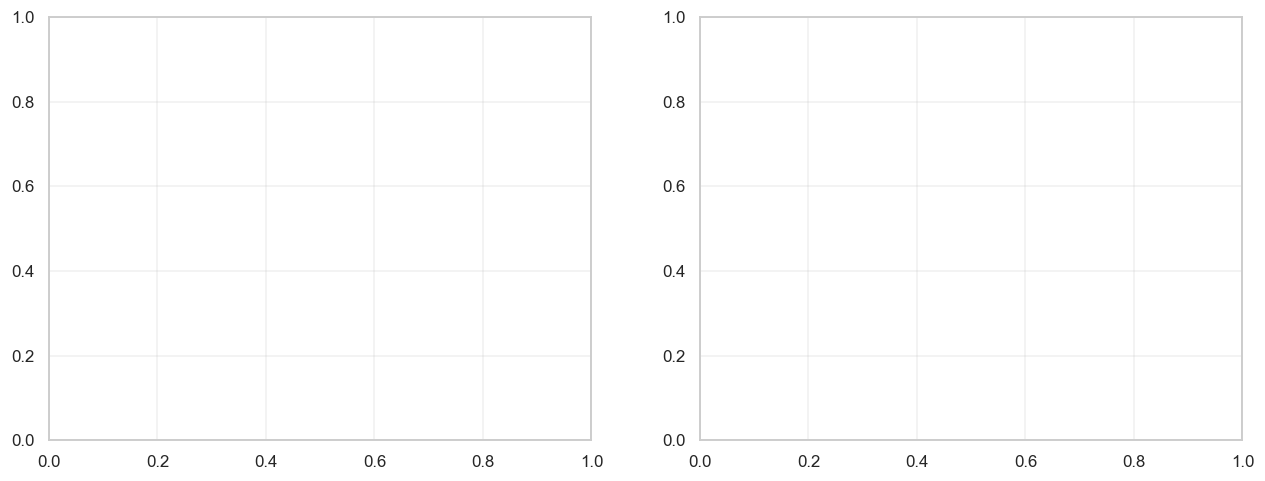

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Corrélation CO2 / Température / Humidité ────────────────
corr_cols = [c for c in ["co2_ppm", "temp_c", "hum_pct"] if c in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    labels = {"co2_ppm": "CO₂ (ppm)", "temp_c": "Température (°C)", "hum_pct": "Humidité (%)"}
    corr.index   = [labels.get(c, c) for c in corr.index]
    corr.columns = [labels.get(c, c) for c in corr.columns]
    sns.heatmap(corr, ax=axes[0], annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, square=True, linewidths=0.5,
                annot_kws={"size": 13, "weight": "bold"})
    axes[0].set_title("Corrélation entre variables", fontweight="bold")

# ── CO2 moyen par mois ───────────────────────────────────────
mois_labels = ["Jan","Fév","Mar","Avr","Mai","Jun",
               "Jul","Aoû","Sep","Oct","Nov","Déc"]
co2_mois = df.groupby("mois")["co2_ppm"].mean()
axes[1].bar([mois_labels[m-1] for m in co2_mois.index],
            co2_mois.values, color="#42A5F5", edgecolor="white")
axes[1].set_title("CO₂ moyen par mois", fontweight="bold")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("CO₂ moyen (ppm)")
axes[1].axhline(df["co2_ppm"].mean(), color="red", linestyle="--",
                linewidth=1.5, label=f"Moyenne globale ({df['co2_ppm'].mean():.0f} ppm)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
print("═" * 60)
print("  RÉSUMÉ EDA — PRÊT POUR LE RAPPORT PFE")
print("═" * 60)

print(f"""
📊 DONNÉES
   Période analysée  : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}
   Nombre de mesures : {len(df):,}
   Fréquence         : 5 minutes (agrégé depuis 30s)

📈 CO₂
   Moyenne globale   : {df['co2_ppm'].mean():.1f} ppm
   Minimum           : {df['co2_ppm'].min():.1f} ppm
   Maximum           : {df['co2_ppm'].max():.1f} ppm
   Écart-type        : {df['co2_ppm'].std():.1f} ppm

🌡️  TEMPÉRATURE
   Moyenne           : {df['temp_c'].mean():.1f} °C  (si disponible)

⚠️  QUALITÉ D'AIR
   Bon (< 800 ppm)   : {100*(df['co2_ppm']<800).mean():.1f}%
   Dégradée          : {100*((df['co2_ppm']>=800)&(df['co2_ppm']<1500)).mean():.1f}%
   Critique (>1500)  : {100*(df['co2_ppm']>=1500).mean():.1f}%

📁 GRAPHIQUES SAUVEGARDÉS
   ✓ eda_co2_6mois.png
   ✓ eda_patterns_temporels.png
   ✓ eda_comparaison_positions.png
   ✓ eda_anomalies.png
   ✓ eda_correlations.png

✅ EDA TERMINÉ — Données validées pour entraînement ML
""")

client.close()
print("Connexion InfluxDB fermée.")

════════════════════════════════════════════════════════════
  RÉSUMÉ EDA — PRÊT POUR LE RAPPORT PFE
════════════════════════════════════════════════════════════


NameError: name 'df' is not defined